In [1]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

class OnlineGaitSegmenter:
    """
    Segments gait data in real-time, one sample at a time.

    This class buffers incoming CPG and gait data. It detects the
    start of a new cycle (a rising zero-crossing in the CPG) to
    dispatch the previously completed cycle.
    """
    
    def __init__(self):
        """Initializes the online segmenter."""
        self.data_buffer = []
        self.last_cpg_val = 0.0
        # We wait for the first zero-crossing to start collecting.
        # This avoids capturing an incomplete partial cycle at the start.
        self.is_collecting = False

    def add_data_point(self, cpg_val: float, data_val) -> np.ndarray | None:
        """
        Processes a single time-step of CPG and gait data.

        Args:
            cpg_val: The CPG signal value at the current time step.
            data_val: The gait data at the current time step.
                      Can be a single float or a list/tuple/array
                      of features (e.g., [joint1, joint2]).

        Returns:
            A 2D NumPy array (shape: (n_steps, n_features)) containing
            one complete gait cycle *only* on the time step that the
            cycle is completed.
            
            Returns `None` on all other time steps.
        """
        
        completed_cycle = None
        
        # --- 1. Detect Rising Zero-Crossing ---
        # (The moment the signal goes from negative to non-negative)
        is_rising_crossing = (self.last_cpg_val < 0) and (cpg_val >= 0)
        
        self.last_cpg_val = cpg_val

        if is_rising_crossing:
            if self.is_collecting:
                # --- 2. A Full Cycle Just Finished ---
                # The buffer holds the complete previous cycle.
                completed_cycle = np.asarray(self.data_buffer)
                
                # Clear the buffer to start collecting the new cycle
                self.data_buffer = []
            else:
                # --- 3. First Crossing Detected ---
                # This is the "true" start. Begin collecting data now.
                self.is_collecting = True

        # --- 4. Buffer Current Data ---
        # If we've passed the first crossing, add the current data
        # to the buffer (which is either new or growing).
        if self.is_collecting:
            self.data_buffer.append(data_val)

        # --- 5. Return the cycle (if one was completed) ---
        if completed_cycle is not None and completed_cycle.size > 0:
             # Ensure output is 2D (timesteps, features)
            if completed_cycle.ndim == 1:
                return completed_cycle.reshape(-1, 1)
            return completed_cycle
        else:
            return None

    def reset(self):
        """Resets the segmenter's internal state."""
        self.data_buffer = []
        self.last_cpg_val = 0.0
        self.is_collecting = False

    @staticmethod
    def normalize_cycle(cycle_data: np.ndarray, num_points: int = 100) -> np.ndarray:
        """
        (Utility Function) Normalizes a *single* completed cycle.

        You would call this on the array returned by `add_data_point`.
        
        Args:
            cycle_data: A 2D array (n_steps, n_features) of one cycle.
            num_points: The target number of points (e.g., 100).

        Returns:
            A 2D array (num_points, n_features) of the normalized cycle.
        """
        if cycle_data.ndim == 1:
            cycle_data = cycle_data.reshape(-1, 1)
            
        cycle_len, num_features = cycle_data.shape
        normalized_cycle = np.zeros((num_points, num_features))

        x_original = np.linspace(0, 1, cycle_len)
        x_normalized = np.linspace(0, 1, num_points)

        for j in range(num_features):
            f = interp1d(x_original, cycle_data[:, j])
            normalized_cycle[:, j] = f(x_normalized)

        return normalized_cycle

Simulating real-time data stream...
  -> Cycle completed at time step 401!
     Cycle length: 200 steps
  -> Cycle completed at time step 601!
     Cycle length: 200 steps
  -> Cycle completed at time step 801!
     Cycle length: 200 steps

Simulation finished.
Total cycles found: 3


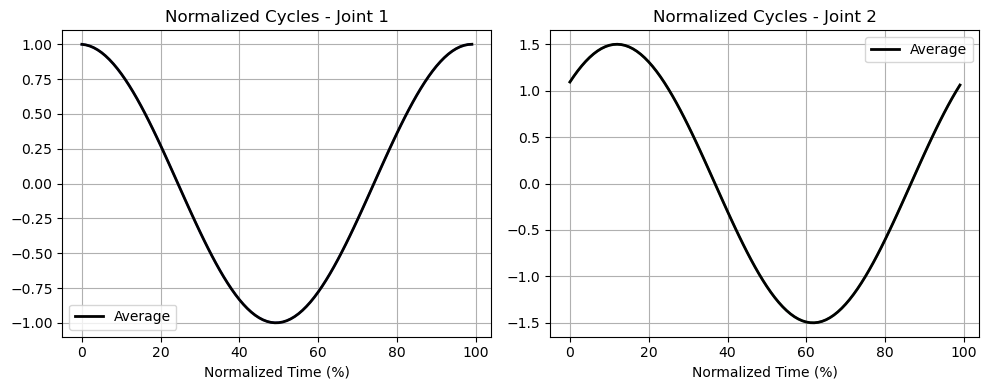

In [2]:
# --- 1. Create Sample Data (same as before) ---
fs = 1000
t = np.linspace(0, 1, fs, endpoint=False)
cpg_signal = np.sin(2 * np.pi * 5 * t)  # 5 Hz CPG
joint_1 = np.cos(2 * np.pi * 5 * t)
joint_2 = 1.5 * np.sin(2 * np.pi * 5 * t + np.pi/4)
gait_data_stream = np.stack([joint_1, joint_2], axis=1) # Shape (1000, 2)

# --- 2. Instantiate the Online Segmenter ---
online_segmenter = OnlineGaitSegmenter()
all_completed_cycles = []
all_normalized_cycles = []

print("Simulating real-time data stream...")

# --- 3. Simulate the Data Stream (The "Online" Loop) ---
# In a real system, this loop would run forever.
for i in range(len(t)):
    
    # Get the "current" data sample
    current_cpg_val = cpg_signal[i]
    current_gait_val = list(gait_data_stream[i, :]) # e.g., [0.98, 1.07]
    
    # Feed the new sample into the segmenter
    completed_cycle = online_segmenter.add_data_point(current_cpg_val, current_gait_val)
    
    # --- 4. Check if a cycle was completed ---
    if completed_cycle is not None:
        print(f"  -> Cycle completed at time step {i}!")
        print(f"     Cycle length: {len(completed_cycle)} steps")
        
        # Immediately normalize the cycle for analysis
        norm_cycle = OnlineGaitSegmenter.normalize_cycle(completed_cycle, num_points=100)
        
        all_completed_cycles.append(completed_cycle)
        all_normalized_cycles.append(norm_cycle)

print("\nSimulation finished.")
print(f"Total cycles found: {len(all_completed_cycles)}")

# --- 5. Plot the Normalized Results ---
if all_normalized_cycles:
    # Stack into a single 3D array (n_cycles, 100, n_features)
    norm_array = np.asarray(all_normalized_cycles)
    
    plt.figure(figsize=(10, 4))
    
    # Plot normalized Joint 1
    plt.subplot(1, 2, 1)
    for cycle in norm_array:
        plt.plot(cycle[:, 0], 'b-', alpha=0.3)
    plt.plot(norm_array.mean(axis=0)[:, 0], 'k-', lw=2, label='Average')
    plt.title('Normalized Cycles - Joint 1')
    plt.xlabel('Normalized Time (%)')
    plt.legend()
    plt.grid(True)

    # Plot normalized Joint 2
    plt.subplot(1, 2, 2)
    for cycle in norm_array:
        plt.plot(cycle[:, 1], 'g-', alpha=0.3)
    plt.plot(norm_array.mean(axis=0)[:, 1], 'k-', lw=2, label='Average')
    plt.title('Normalized Cycles - Joint 2')
    plt.xlabel('Normalized Time (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()